In [1]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os
import glob
import re

In [2]:
# --- File paths ---
File_Eki = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnKi1_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnKi1_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnKi1_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnKi1_ApJ_.h5'
]

File_Emag = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnMa_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnMa_ApJ_.h5'
]

File_Etot = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnTot_ApJ_.h5'
]

File_Time = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/Time_ApJ_.h5'
]

labels = [
    'η = 0.625×10⁻⁴',
    'η = 1.25×10⁻⁴',
    'η = 2.5×10⁻⁴',
    'η = 5×10⁻⁴'
]

In [6]:
def load_dataset(fp):
    with h5py.File(fp, "r") as f:
        key = list(f.keys())[0]
        return f[key][:]

# --- Load all energies ---
Emag, Ekin, Etot, times = [], [], [], []

for fmag, fkin, ftot, ftime in zip(File_Emag, File_Eki, File_Etot, File_Time):
    Emag.append(load_dataset(fmag))
    Ekin.append(load_dataset(fkin))
    Etot.append(load_dataset(ftot))
    times.append(load_dataset(ftime))

# --- Construct total from components ---
Etot_from_parts = [Em + Ek + 0.75 for Em, Ek in zip(Emag, Ekin)]

In [7]:
colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
]

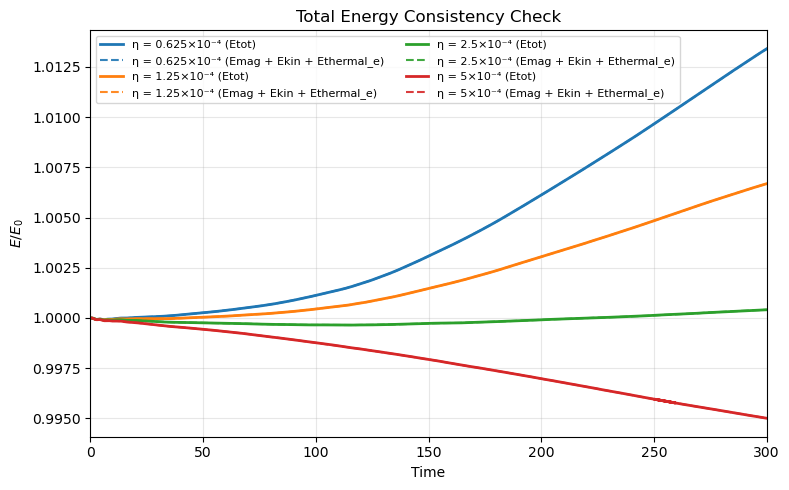

In [9]:
plt.figure(figsize=(8, 5))
plt.xlim(0, 300)

for t, Et_file, Et_parts, label, color in zip(
        times, Etot, Etot_from_parts, labels, colors):

    # Total energy from file
    plt.plot(
        t,
        Et_file / Et_file[0],
        color=color,
        lw=2,
        label=f"{label} (Etot)"
    )

    # Sum of magnetic + kinetic
    plt.plot(
        t,
        Et_parts / Et_parts[0],
        color=color,
        lw=1.5,
        ls="--",
        alpha=0.9,
        label=f"{label} (Emag + Ekin + Ethermal_e)"
    )

plt.xlabel("Time")
plt.ylabel(r"$E / E_0$")
plt.title("Total Energy Consistency Check")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("TotalEnergyComparison.png", dpi=300)
plt.show()

In [45]:
#Comparing Kinetic Energy Calculated vs Written
EKin_file = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnKi1_ApJ_.h5'
Time_file = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Time_ApJ_.h5'

with h5py.File(EKin_file, 'r') as f:
    Ekin = f[list(f.keys())[0]][:]

with h5py.File(Time_file, 'r') as f:
    time = f[list(f.keys())[0]][:]

vel_dir = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'

def extract_timestep(fname):
    return int(re.search(r'_t(\d+)\.h5$', fname).group(1))

Ux_files = glob.glob(os.path.join(vel_dir, 'Ux1_ApJ_t*.h5'))
Ux_files = sorted(Ux_files, key=extract_timestep)

Bx_files = glob.glob(os.path.join(vel_dir, 'Bx_ApJ_t*.h5'))
Bx_files = sorted(Bx_files, key=extract_timestep)

# File_P_par = f'/DATA/DEVESH/ApJ2015/Ppar1_ApJ_t{i}.h5'  # Replace with your file path
#     File_P_per = f'/DATA/DEVESH/ApJ2015/Pper1_ApJ_t{i}.h5'  # Replace with your file path
#     File_Dn = f'/DATA/DEVESH/ApJ2015/Dn1_ApJ_t{i}.h5'
    
#     File_Bx = f'/DATA/DEVESH/ApJ2015/Bx_ApJ_t{i}.h5'
#     File_By = f'/DATA/DEVESH/ApJ2015/By_ApJ_t{i}.h5'

#     with h5py.File(File_P_par, 'r') as fPpar, h5py.File(File_P_per, 'r') as fPper, h5py.File(File_Dn, 'r') as fDn:
#         data_P_par = fPpar['DS1'][:]
#         data_P_per = fPper['DS1'][:]
#         data_Dn = fDn['DS1'][:]
#         data_T_per = data_P_per/data_Dn
#         data_T_par = data_P_par/data_Dn
#         data_Aniso = data_T_per/data_T_par

#     avg1 = np.mean(data_T_per/T_naught)
#     avg2 = np.mean(data_T_par/T_naught)
#     avg3 = np.mean(data_Aniso)
#     T_perp_avg.append(avg1)
#     T_par_avg.append(avg2)
#     Aniso_avg.append(avg3)

Ekin_from_U = []
timesteps = []

for ux_file in Ux_files:
    t = extract_timestep(ux_file)
    timesteps.append(t)

    uy_file = os.path.join(vel_dir, f'Uy1_ApJ_t{t}.h5')
    uz_file = os.path.join(vel_dir, f'Uz1_ApJ_t{t}.h5')

    n_file = os.path.join(vel_dir, f'Dn1_ApJ_t{t}.h5')

    bx_file = os.path.join(vel_dir, f'Bx_ApJ_t{t}.h5')
    by_file = os.path.join(vel_dir, f'By_ApJ_t{t}.h5')
    bz_file = os.path.join(vel_dir, f'Bz_ApJ_t{t}.h5')

    ppar_file = os.path.join(vel_dir, f'Ppar1_ApJ_t{t}.h5')
    pper_file = os.path.join(vel_dir, f'Pper1_ApJ_t{t}.h5')

    with h5py.File(ux_file, 'r') as f:
        Ux = f[list(f.keys())[0]][:]

    with h5py.File(uy_file, 'r') as f:
        Uy = f[list(f.keys())[0]][:]

    with h5py.File(uz_file, 'r') as f:
        Uz = f[list(f.keys())[0]][:]

    with h5py.File(n_file, 'r') as f:
        n = f[list(f.keys())[0]][:]

    with h5py.File(bx_file, 'r') as f:
        Bx = f[list(f.keys())[0]][:]

    with h5py.File(by_file, 'r') as f:
        By = f[list(f.keys())[0]][:]

    with h5py.File(bz_file, 'r') as f:
        Bz = f[list(f.keys())[0]][:]

    with h5py.File(ppar_file, 'r') as f:
        Ppar = f[list(f.keys())[0]][:]
        
    with h5py.File(pper_file, 'r') as f:
        Pper = f[list(f.keys())[0]][:]

    Ux = Ux
    Uy = Uy
    Uz = Uz

    # Bulk kinetic energy: (1/2) * m * <u^2>
    E_bulk = 0.5 * np.sum(Ux**2 + Uy**2 + Uz**2)

    # Thermal energy: (1/2) * <Ppar + 2*Pper> = (1/2) * <n*(Tpar + 2*Tper)>
    # Since P = n*T, we have:
    E_thermal = 0.5 * np.sum(Ppar + 2.0 * Pper)

    Ekin_t = E_bulk + E_thermal

    Ekin_from_U.append(Ekin_t)
    print(ux_file)

Ekin_from_U = np.array(Ekin_from_U)
timesteps = np.array(timesteps)

/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t0.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t1.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t2.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t3.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t4.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t5.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t6.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t7.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t8.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t9.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t10.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t11.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t12.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t13.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t14.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t15.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Ux1_ApJ_t16.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048

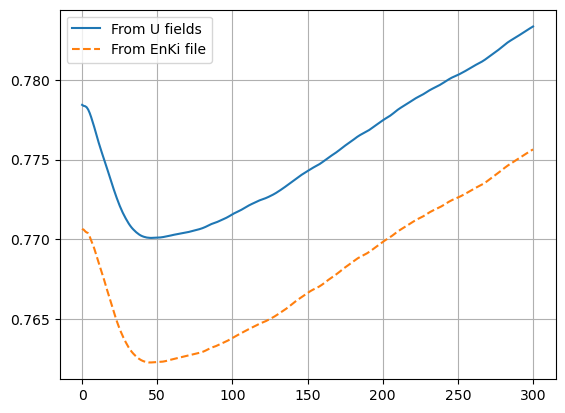

In [44]:
plt.plot(timesteps, Ekin_from_U/16777216, label='From U fields')
plt.plot(time, Ekin, '--', label='From EnKi file')
plt.legend()
plt.grid()
plt.show()

In [46]:
import numpy as np
import h5py
import glob
import os
import re

# Parameters - VERIFY FROM YOUR INPUT FILE
sm1 = 1.0  # species mass

# File paths
vel_dir = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'
EKin_file = os.path.join(vel_dir, 'EnKi1_ApJ_.h5')
Time_file = os.path.join(vel_dir, 'Time_ApJ_.h5')

with h5py.File(EKin_file, 'r') as f:
    Ekin_hist = f[list(f.keys())[0]][:]
with h5py.File(Time_file, 'r') as f:
    time_hist = f[list(f.keys())[0]][:]

def extract_timestep(fname):
    return int(re.search(r'_t(\d+)\.h5$', fname).group(1))

Ux_files = sorted(glob.glob(os.path.join(vel_dir, 'Ux1_ApJ_t*.h5')), key=extract_timestep)

Ekin_from_U = []
Ekin_bulk_arr = []
Ekin_thermal_arr = []
timesteps = []

for ux_file in Ux_files:
    t = extract_timestep(ux_file)
    timesteps.append(t)
    
    uy_file = os.path.join(vel_dir, f'Uy1_ApJ_t{t}.h5')
    uz_file = os.path.join(vel_dir, f'Uz1_ApJ_t{t}.h5')
    n_file = os.path.join(vel_dir, f'Dn1_ApJ_t{t}.h5')
    ppar_file = os.path.join(vel_dir, f'Ppar1_ApJ_t{t}.h5')
    pper_file = os.path.join(vel_dir, f'Pper1_ApJ_t{t}.h5')
    
    with h5py.File(ux_file, 'r') as f:
        nUx = f[list(f.keys())[0]][:]
    with h5py.File(uy_file, 'r') as f:
        nUy = f[list(f.keys())[0]][:]
    with h5py.File(uz_file, 'r') as f:
        nUz = f[list(f.keys())[0]][:]
    with h5py.File(n_file, 'r') as f:
        n = f[list(f.keys())[0]][:]
    with h5py.File(ppar_file, 'r') as f:
        Ppar = f[list(f.keys())[0]][:]
    with h5py.File(pper_file, 'r') as f:
        Pper = f[list(f.keys())[0]][:]
    
    # Get velocities (Ux files contain n*u, so divide by n)
    Ux = nUx / n
    Uy = nUy / n
    Uz = nUz / n
    
    # Bulk kinetic energy: (1/2) * m * <u^2>
    E_bulk = 0.5 * sm1 * np.mean(Ux**2 + Uy**2 + Uz**2)
    
    # Thermal energy: (1/2) * <Ppar + 2*Pper>
    # P = n*T, so this equals (1/2) * <n*(Tpar + 2*Tper)>
    E_thermal = 0.5 * np.mean(Ppar + 2.0 * Pper)
    
    # Total kinetic energy
    Ekin_t = E_bulk + E_thermal
    
    Ekin_from_U.append(Ekin_t)
    Ekin_bulk_arr.append(E_bulk)
    Ekin_thermal_arr.append(E_thermal)
    
    print(f"t={t}: E_bulk={E_bulk:.6f}, E_therm={E_thermal:.6f}, E_total={Ekin_t:.6f}")

Ekin_from_U = np.array(Ekin_from_U)
Ekin_bulk_arr = np.array(Ekin_bulk_arr)
Ekin_thermal_arr = np.array(Ekin_thermal_arr)
timesteps = np.array(timesteps)

# Compare at matching timesteps
print("\n--- Comparison ---")
print(f"EnKi from hist (first few): {Ekin_hist[:5]}")
print(f"EnKi reconstructed (first few): {Ekin_from_U[:5]}")
print(f"Ratio: {Ekin_from_U[:5] / Ekin_hist[:5]}")

t=0: E_bulk=0.028663, E_therm=0.749766, E_total=0.778429
t=1: E_bulk=0.028358, E_therm=0.750007, E_total=0.778366
t=2: E_bulk=0.028277, E_therm=0.750071, E_total=0.778347
t=3: E_bulk=0.028434, E_therm=0.749854, E_total=0.778289
t=4: E_bulk=0.028025, E_therm=0.750138, E_total=0.778163
t=5: E_bulk=0.027737, E_therm=0.750244, E_total=0.777980
t=6: E_bulk=0.027734, E_therm=0.750024, E_total=0.777758
t=7: E_bulk=0.027239, E_therm=0.750278, E_total=0.777517
t=8: E_bulk=0.026853, E_therm=0.750412, E_total=0.777265
t=9: E_bulk=0.026787, E_therm=0.750207, E_total=0.776994
t=10: E_bulk=0.026399, E_therm=0.750315, E_total=0.776715
t=11: E_bulk=0.026061, E_therm=0.750374, E_total=0.776435
t=12: E_bulk=0.025976, E_therm=0.750174, E_total=0.776149
t=13: E_bulk=0.025584, E_therm=0.750269, E_total=0.775853
t=14: E_bulk=0.025154, E_therm=0.750396, E_total=0.775549
t=15: E_bulk=0.024956, E_therm=0.750276, E_total=0.775232
t=16: E_bulk=0.024584, E_therm=0.750318, E_total=0.774901
t=17: E_bulk=0.024172, E

In [48]:
import numpy as np
import h5py
import glob
import os
import re

sm1 = 1.0

vel_dir = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'
EKin_file = os.path.join(vel_dir, 'EnKi1_ApJ_.h5')
Time_file = os.path.join(vel_dir, 'Time_ApJ_.h5')

with h5py.File(EKin_file, 'r') as f:
    Ekin_hist = f[list(f.keys())[0]][:]
with h5py.File(Time_file, 'r') as f:
    time_hist = f[list(f.keys())[0]][:]

def extract_timestep(fname):
    return int(re.search(r'_t(\d+)\.h5$', fname).group(1))

Ux_files = sorted(glob.glob(os.path.join(vel_dir, 'Ux1_ApJ_t*.h5')), key=extract_timestep)

# Initialize as LISTS, not arrays
Ekin_from_U_old = []
Ekin_from_U_new = []
Ekin_from_U_alt = []
timesteps = []

for ux_file in Ux_files:
    t = extract_timestep(ux_file)
    timesteps.append(t)
    
    # Load files
    with h5py.File(os.path.join(vel_dir, f'Ux1_ApJ_t{t}.h5'), 'r') as f:
        nUx = f[list(f.keys())[0]][:]
    with h5py.File(os.path.join(vel_dir, f'Uy1_ApJ_t{t}.h5'), 'r') as f:
        nUy = f[list(f.keys())[0]][:]
    with h5py.File(os.path.join(vel_dir, f'Uz1_ApJ_t{t}.h5'), 'r') as f:
        nUz = f[list(f.keys())[0]][:]
    with h5py.File(os.path.join(vel_dir, f'Dn1_ApJ_t{t}.h5'), 'r') as f:
        n = f[list(f.keys())[0]][:]
    with h5py.File(os.path.join(vel_dir, f'Ppar1_ApJ_t{t}.h5'), 'r') as f:
        Ppar = f[list(f.keys())[0]][:]
    with h5py.File(os.path.join(vel_dir, f'Pper1_ApJ_t{t}.h5'), 'r') as f:
        Pper = f[list(f.keys())[0]][:]
    
    # Method 1: Original method (your current approach)
    Ux = nUx / n
    Uy = nUy / n
    Uz = nUz / n
    E_bulk_old = 0.5 * sm1 * np.mean(Ux**2 + Uy**2 + Uz**2)
    
    # Method 2: Density-weighted
    E_bulk_new = 0.5 * sm1 * np.mean((nUx**2 + nUy**2 + nUz**2) / n) / np.mean(n)
    
    # Method 3: Alternative using momentum
    mean_n = np.mean(n)
    E_bulk_alt = 0.5 * sm1 * np.mean(nUx**2 + nUy**2 + nUz**2) / (mean_n * mean_n)
    
    # Thermal energy (same for all methods)
    E_thermal = 0.5 * np.mean(Ppar + 2.0 * Pper)
    
    # Total energies
    Ekin_from_U_old.append(E_bulk_old + E_thermal)
    Ekin_from_U_new.append(E_bulk_new + E_thermal)
    Ekin_from_U_alt.append(E_bulk_alt + E_thermal)

# Convert to arrays AFTER the loop
Ekin_from_U_old = np.array(Ekin_from_U_old)
Ekin_from_U_new = np.array(Ekin_from_U_new)
Ekin_from_U_alt = np.array(Ekin_from_U_alt)
timesteps = np.array(timesteps)

# Compare
print("--- Comparison ---")
print(f"EnKi from hist:  {Ekin_hist[:5]}")
print(f"Old method:      {Ekin_from_U_old[:5]}")
print(f"New method:      {Ekin_from_U_new[:5]}")
print(f"Alt method:      {Ekin_from_U_alt[:5]}")
print(f"Ratio (old):     {Ekin_from_U_old[:5] / Ekin_hist[:5]}")
print(f"Ratio (new):     {Ekin_from_U_new[:5] / Ekin_hist[:5]}")
print(f"Ratio (alt):     {Ekin_from_U_alt[:5] / Ekin_hist[:5]}")

--- Comparison ---
EnKi from hist:  [0.77065086 0.77062935 0.77061987 0.7706125  0.770598  ]
Old method:      [0.7784288  0.77836555 0.7783474  0.7782889  0.7781633 ]
New method:      [0.77842873 0.77836466 0.7783439  0.7782806  0.7781446 ]
Alt method:      [0.7784315  0.77836883 0.7783463  0.77828085 0.7781386 ]
Ratio (old):     [1.0100927 1.0100389 1.0100276 1.0099615 1.0098175]
Ratio (new):     [1.0100926 1.0100377 1.0100231 1.0099508 1.0097932]
Ratio (alt):     [1.0100962 1.010043  1.0100262 1.009951  1.0097854]


In [40]:
print(np.size(timesteps))
print(np.size(time))
print(Ekin_from_U[0]/Ekin[0]/16777216)
print(1.0100927*16777216)

301
1201
1.0100927
16946543.4079232


In [ ]:
#Comparing Magnetic Energy Calculated vs Written
EMag_file = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnMa_ApJ_.h5'
Time_file = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Time_ApJ_.h5'

with h5py.File(EMag_file, 'r') as f:
    Emag = f[list(f.keys())[0]][:]

with h5py.File(Time_file, 'r') as f:
    time = f[list(f.keys())[0]][:]

vel_dir = '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'

def extract_timestep(fname):
    return int(re.search(r'_t(\d+)\.h5$', fname).group(1))

Bx_files = glob.glob(os.path.join(vel_dir, 'Bx_ApJ_t*.h5'))
Bx_files = sorted(Bx_files, key=extract_timestep)

Emag_from_B = []
timesteps = []

for bx_file in Bx_files:
    t = extract_timestep(bx_file)
    timesteps.append(t)

    by_file = os.path.join(vel_dir, f'By_ApJ_t{t}.h5')
    bz_file = os.path.join(vel_dir, f'Bz_ApJ_t{t}.h5')


    with h5py.File(bx_file, 'r') as f:
        Bx = f[list(f.keys())[0]][:]

    with h5py.File(by_file, 'r') as f:
        By = f[list(f.keys())[0]][:]

    with h5py.File(bz_file, 'r') as f:
        Bz = f[list(f.keys())[0]][:]
    
    Emag_t = 0.5 * np.sum(Bx**2 + By**2 + Bz**2)
    Emag_from_B.append(Emag_t)

    # print(bx_file)

Emag_from_B = np.array(Emag_from_B)
timesteps = np.array(timesteps)

/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t0.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t1.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t2.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t3.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t4.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t5.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t6.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t7.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t8.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t9.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t10.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t11.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t12.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t13.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t14.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t15.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t16.h5
/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t17.h5
/D

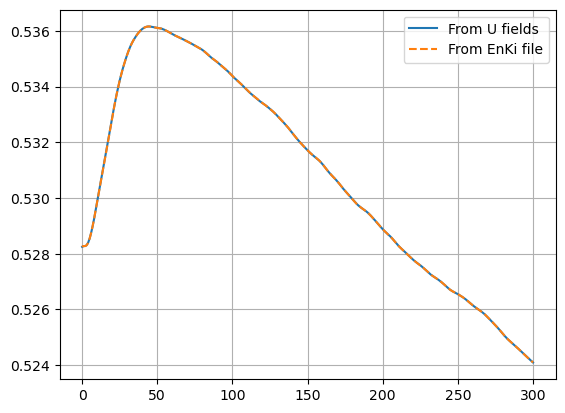

In [40]:
plt.plot(timesteps, Emag_from_B/16777216, label='From B fields')
plt.plot(time, Emag, '--', label='From EnMa file')
# plt.plot(time, Emag/Emag_from_U, '--', label='From EnKi file')
plt.legend()
plt.grid()
plt.show()

1201

In [43]:
# Emag_from_U[0]/Emag[0]
Ekin_from_U[0]/Ekin[0]

np.float32(624004.75)